In [16]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple
import json
import numpy as np
import xmltodict


def load_data_and_calibration(npz_path: str | Path, xml_path: str | Path) -> tuple[np.ndarray, float, float]:
    """
    Load spectrum data + parse dispersion/offset from AutoScript metadata XML.
    Returns (data, dispersion, offset).
    """
    npz_path = Path(npz_path)
    xml_path = Path(xml_path)

    # --- load data ---
    # data = np.load(npz_path)["data"]
    
    ## npy load
    data = np.load(npz_path)[0]

    # --- load + parse XML ---
    xml_string = xml_path.read_text(encoding="utf-8")
    metadata = xmltodict.parse(xml_string)
    metadata = json.loads(json.dumps(metadata))  # normalize to plain dict

    detectors = metadata["Metadata"]["Detectors"]["AnalyticalDetector"]
    if isinstance(detectors, dict):
        detectors = [detectors]

    det = detectors[0]  # or filter by Name later if needed
    dispersion = float(det.get("Dispersion", 0))
    offset = float(det.get("OffsetEnergy", 0))

    return data, dispersion, offset

In [17]:
import sidpy
import numpy as np


def sidpy_spectrum_from_disk(npz_path: str | Path, xml_path: str | Path, dispersion_constant = 1.003) -> sidpy.Dataset:
    """
    Read saved spectrum + XML, build a sidpy.Dataset with Energy axis in eV.
    """
    data, dispersion, offset = load_data_and_calibration(npz_path, xml_path)

    # --- energy axis ---
    energy = np.arange(data.shape[0], dtype=float) * dispersion*dispersion_constant + offset

    # --- sidpy dataset ---
    ds = sidpy.Dataset.from_array(data)
    ds.data_type = "spectrum"
    ds.quantity = "Intensity"
    ds.units = "counts"

    ds.set_dimension(0, sidpy.Dimension(energy, name="Energy", units="eV", quantity="Energy",dimension_type='spectral'
))

    # (optional) keep raw XML around
    ds.metadata = {"autoscript_xml_path": str(xml_path), "dispersion": dispersion, "offset": offset}

    return ds

In [18]:
ds = sidpy_spectrum_from_disk("/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/notebooks/multimodal-data-process/20260228_114447_stem_edx_1772297087/raw_spectra.npy", "my_run/eds_0001.xml", dispersion_constant = 1.003)
print(ds)

sidpy.Dataset of type SPECTRUM with:
 dask.array<array, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
 data contains: Intensity (counts)
 and Dimensions: 
Energy:  Energy (eV) of size (4096,)
 with metadata: ['autoscript_xml_path', 'dispersion', 'offset']


In [15]:
ds = sidpy_spectrum_from_disk("my_run/eds_0001.npz", "my_run/eds_0001.xml", dispersion_constant = 1.003)
print(ds)

sidpy.Dataset of type SPECTRUM with:
 dask.array<array, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
 data contains: Intensity (counts)
 and Dimensions: 
Energy:  Energy (eV) of size (4096,)
 with metadata: ['autoscript_xml_path', 'dispersion', 'offset']


In [10]:
##### set more metadata about detector - I dont get it but 
### Does not work for spectrum images
# 

import pyTEMlib
spectrum = ds
start = np.searchsorted(spectrum.Energy.values, 100)
energy_scale = spectrum.Energy.values[start:]
spectrum.metadata.setdefault('EDS', {})
spectrum.metadata['EDS'].setdefault('detector', {})
spectrum.metadata['EDS']['detector'] = {'layers': {13: {'thickness': 5e-08, 'Z': 13, 'element': 'Al'}},
 'SiDeadThickness': 1.3e-07,
 'SiLiveThickness': 0.05,
 'detector_area': 2.9999999999999997e-05,
 'energy_resolution': 125,
 'start_energy': 120,
 'start_channel': 100,
 'ElevationAngle': 0.31415927,
 'AzimuthAngle': 3.9269908169872414,
 'RealTime': 26.2338126,
 'LiveTime': 25.20496870466589}

detector_Efficiency= pyTEMlib.eds_tools.detector_response(spectrum)  # tags, spectrum.energy_scale.values[start:])


spectrum.metadata['EDS']['detector'].setdefault('start_energy',  120)
spectrum.metadata['EDS']['detector']['start_channel'] = np.searchsorted(spectrum.Energy.values, spectrum.metadata['EDS']['detector']['start_energy'])
start = spectrum.metadata['EDS']['detector']['start_channel']
spectrum[:spectrum.metadata['EDS']['detector']['start_channel']] = 100.

spectrum.metadata['EDS']['detector']['detector_efficiency']  = detector_Efficiency

/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/.venv/lib/python3.11/site-packages/dask/array/core.py:1738: FutureWarning: The `numpy.argsort` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


['Fe', 'Na', 'Br']

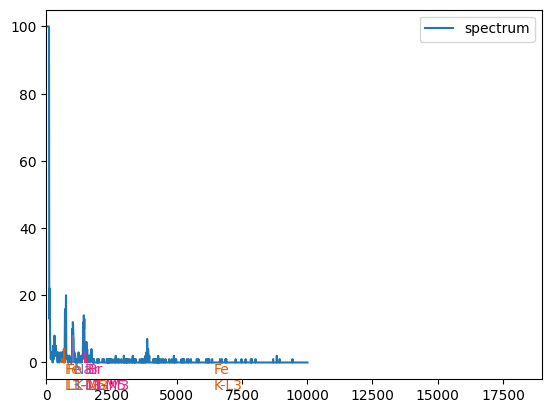

In [11]:
# FInd elements
# --------Input -----------
minimum_number_of_peaks = 10
# --------------------------
%matplotlib inline
import sys
import numpy as np
import matplotlib.pylab as plt

elements = pyTEMlib.eds_tools.get_elements(spectrum, minimum_number_of_peaks, verbose=False)

plt.figure()
plt.plot(spectrum.Energy,spectrum, label = 'spectrum')
pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS'], plt.gca())
plt.legend();
plt.xlim(0,19000)
elements

In [12]:
## Add Mg
def add_element(spectrum, elements):
    if isinstance(elements, str):
        elements = [elements]
    if not isinstance(elements, list):
        raise ValueError("elements must be a string or a list of strings")
    spectrum.metadata['EDS'].update(pyTEMlib.eds_tools.get_x_ray_lines(spectrum, elements))

add_element(spectrum, ['Fe','Ni', 'Cr'])   


In [13]:
# quantify 
peaks, pp = pyTEMlib.eds_tools.fit_model(spectrum, use_detector_efficiency=True)
q_dict = pyTEMlib.eds_tools.load_k_factors()

import io
import contextlib

f = io.StringIO()
with contextlib.redirect_stdout(f):
    pyTEMlib.eds_tools.quantify_eds(spectrum, q_dict, mask=['C','F','Ne'])

output = f.getvalue()
print(output)
results = {}

for line in output.splitlines():
    if ":" in line and "at%" in line:
        element, rest = line.split(":")
        parts = rest.strip().split()
        at = float(parts[0])
        wt = float(parts[2])
        results[element.strip()] = {"at%": at, "wt%": wt}

print(results)



using cross sections for quantification
Fe: -2.18 at% -2.95 wt%
Na: 70.10 at% 39.11 wt%
Br: 34.61 at% 67.12 wt%
Ni: -0.54 at% -0.77 wt%
Cr: -1.99 at% -2.51 wt%

{'Fe': {'at%': -2.18, 'wt%': -2.95}, 'Na': {'at%': 70.1, 'wt%': 39.11}, 'Br': {'at%': 34.61, 'wt%': 67.12}, 'Ni': {'at%': -0.54, 'wt%': -0.77}, 'Cr': {'at%': -1.99, 'wt%': -2.51}}


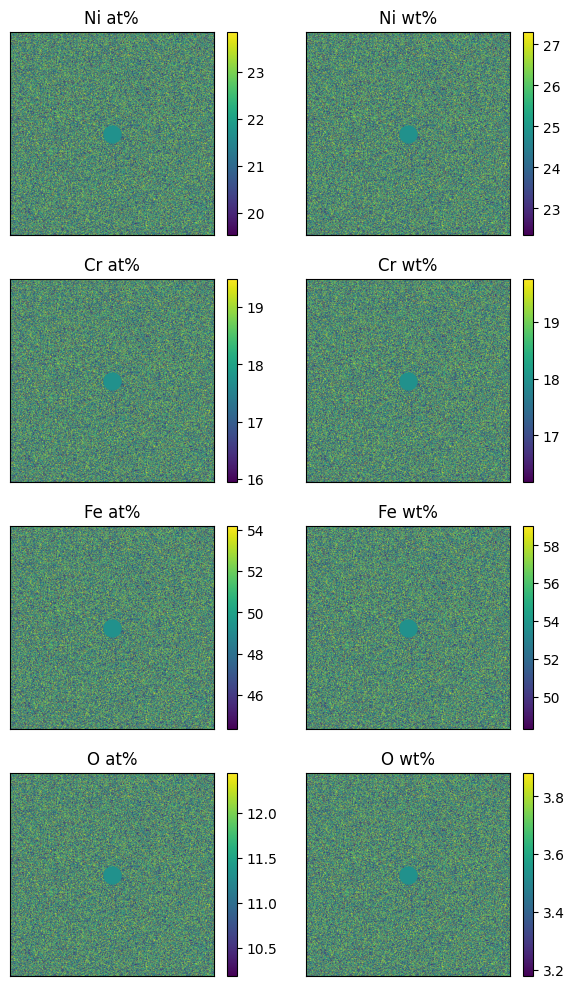

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# given EDX result at one location
edx = {
    'Ni': {'at%': 21.69, 'wt%': 24.83},
    'Cr': {'at%': 17.72, 'wt%': 17.97},
    'Fe': {'at%': 49.27, 'wt%': 53.67},
    'O':  {'at%': 11.32, 'wt%': 3.53}
}

# random 512x512 image
img = np.random.rand(512, 512)

# normalized (0.5, 0.5) -> pixel coords
x = int(512 * 0.5)
y = int(512 * 0.5)

elements = list(edx.keys())

fig, axes = plt.subplots(len(elements), 2, figsize=(6, 10))

for i, el in enumerate(elements):
    for j, key in enumerate(['at%', 'wt%']):
        ax = axes[i, j]
        ax.imshow(img, origin='upper')
        val = edx[el][key]
        sc = ax.scatter([x], [y], c=[val], s=150)
        ax.set_title(f"{el} {key}")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()